# Tune $D_{sei}$ to get SEI quality for different formation protocols

2025/04/16

The plan:
1. Define an objective function as some combination of expansion error and voltage error
1. Sweep through different values of D_sei for VC only (just start with VC for now)
1. Plot D_sei vs error function for the three different formation protocols

Andrew Weng

In [2]:
import os, sys

# Move the path up a level to be able to index into source files
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('../')
    sys.path.insert(0, 'src/')

from src import cellsim as cellsim

from scipy.interpolate import interp1d

import pickle
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from src import plotter as plotter
from src import ioutils as ioutils 
from src import simutils as simutils

%load_ext autoreload
%matplotlib widget

plotter.initialize(plt)

In [6]:
expt1, _ = ioutils.fetch_experimental_data(152064, 400)
expt2, _ = ioutils.fetch_experimental_data(152074, 400)
expt3, _ = ioutils.fetch_experimental_data(152071, 400)
expt4, _ = ioutils.fetch_experimental_data(152098, 400)


dt_data_interp = 1.0
t_interp1, i_interp1 = simutils.interpolate_raw_data(expt1['arbin_time'], expt1['arbin_current'], dt_data_interp)
t_interp2, i_interp2 = simutils.interpolate_raw_data(expt2['arbin_time'], expt2['arbin_current'], dt_data_interp)
t_interp3, i_interp3 = simutils.interpolate_raw_data(expt3['arbin_time'], expt3['arbin_current'], dt_data_interp)
t_interp4, i_interp4 = simutils.interpolate_raw_data(expt4['arbin_time'], expt4['arbin_current'], dt_data_interp)

In [8]:
# Define affected regions for each dataset
# Format: (expt, label, t_start, t_end)
kink_regions = [
    (expt1, 'Base 1', 0.5, 0.75),
    (expt2, 'Base 2', 0.5, 0.85),
    (expt3, 'Fast', 0.5, 0.6),
    (expt4, 'Fast+', 0.5, 0.55),
]

# Apply smoothing to each dataset
smoothed_strains = {}
for expt, label, t_start, t_end in kink_regions:
    daq_time = np.array(expt['daq_time'])
    daq_strain = np.array(expt['daq_strain'])
    
    # Convert to hours from zero
    daq_time_hours = (daq_time - daq_time[0]) / 3600.0
    
    # Apply smoothing
    strain_smoothed = ioutils.smooth_kink_region(daq_time_hours, daq_strain, t_start, t_end)
    smoothed_strains[label] = {
        'time_hours': daq_time_hours,
        'original': daq_strain,
        'smoothed': strain_smoothed,
        't_start': t_start,
        't_end': t_end
    }

expt1['daq_strain_smoothed'] = smoothed_strains['Base 1']['smoothed']
expt2['daq_strain_smoothed'] = smoothed_strains['Base 2']['smoothed']
expt3['daq_strain_smoothed'] = smoothed_strains['Fast']['smoothed']
expt4['daq_strain_smoothed'] = smoothed_strains['Fast+']['smoothed']

# Study sensitivity of model error to choice of {$D_1$, $D_2$}

In [ ]:
%matplotlib widget 

# Optimized densities from baseline formation, expansion RMSE
rho_vc_opt = 1.3
rho_ec_opt = 0.8

d_ec = 3.86e-20
d_vc = 1.585e-17

df_base = simutils.run_sim('base', d_ec, d_vc, rho_ec=rho_ec_opt, rho_vc=rho_vc_opt, dt=1, include_flag=1)

fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)

# Experimental data (fast protocol)
exp_time = expt1['daq_time'] / 3600  # convert seconds to hours
exp_strain = expt1['daq_strain']

exp_time2 = expt2['daq_time'] / 3600  # convert seconds to hours
exp_strain2 = expt2['daq_strain']

# Model data
model_time = df_base['t'] / 3600  # convert seconds to hours
model_expansion = df_base['expansion'] * 1e6  # convert m to um

# Top plot: Expansion
axes[0].plot(exp_time, exp_strain, label='Experimental 1', color='k', lw=2)
axes[0].plot(exp_time2, exp_strain2, label='Experimental 2', color='gray', lw=2, linestyle='-')
axes[0].plot(model_time, model_expansion, label='Model', color='tab:blue', lw=2, ls='--')
axes[0].set_ylabel('Expansion (µm)')
axes[0].set_title('Model vs Experimental Expansion (Base Protocol)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Bottom plot: SEI current densities
axes[1].plot(model_time, df_base['j_sei1'], label='j_sei1 (EC)', color='tab:orange', lw=2)
axes[1].plot(model_time, df_base['j_sei2'], label='j_sei2 (VC)', color='tab:green', lw=2)
axes[1].set_xlabel('Time (hours)')
axes[1].set_ylabel('Current density (A/m²)')
axes[1].set_title('SEI Current Densities (Base Protocol)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

# Set shared x-axis limits
axes[1].set_xlim(0.4, 5)

plt.tight_layout()
plt.show()

# Study sensitivity of model error to choice of {DSEI1, DSEI2}

In [4]:
nn = 35

diff_ec_vec = np.logspace(-22, -17, nn)
diff_vc_vec = np.logspace(-21, -12, nn+1)

shape = (len(diff_ec_vec), len(diff_vc_vec))
_mat_names = [
    'rmse1_e_mat', 'rmse1_v_mat', 'rmse2_e_mat', 'rmse2_v_mat', 'rmse3_e_mat', 'rmse3_v_mat',
    'qsei1_mat', 'qsei2_mat', 'qsei3_mat', 'qsei1_vc_mat', 'qsei2_vc_mat', 'qsei3_vc_mat',
    'expan1_mat', 'expan2_mat', 'expan3_mat',
    'resistance1_mat', 'resistance2_mat', 'resistance3_mat',
    'crosstime1_mat', 'crosstime2_mat', 'crosstime3_mat',
]
mats = {n: np.zeros(shape) for n in _mat_names}
(rmse1_e_mat, rmse1_v_mat, rmse2_e_mat, rmse2_v_mat, rmse3_e_mat, rmse3_v_mat,
 qsei1_mat, qsei2_mat, qsei3_mat, qsei1_vc_mat, qsei2_vc_mat, qsei3_vc_mat,
 expan1_mat, expan2_mat, expan3_mat, resistance1_mat, resistance2_mat, resistance3_mat,
 crosstime1_mat, crosstime2_mat, crosstime3_mat) = tuple(mats[n] for n in _mat_names)

count = 1

# Optimized densities from baseline formation, expansion RMSE
rho_vc_opt = 1.49
rho_ec_opt = 1.29
kappa_vc_opt = 0.051e-3
kappa_ec_opt = 0.090e-3


for i, diff_ec in enumerate(diff_ec_vec):
    for j, diff_vc in enumerate(diff_vc_vec):

        print(f'Running D_EC = {diff_ec:.2e} m2/s and D_VC = {diff_vc:.2e} m2/s ({count} of {nn*(nn+1)})')
        count += 1

        try:
            df_sim1 = simutils.run_sim('base', diff_ec, diff_vc, rho_ec=rho_ec_opt, rho_vc=rho_vc_opt, kappa_ec=kappa_ec_opt, kappa_vc=kappa_vc_opt, dt=1, include_flag=0)
            df_sim2 = simutils.run_sim('fast', diff_ec, diff_vc, rho_ec=rho_ec_opt, rho_vc=rho_vc_opt, kappa_ec=kappa_ec_opt, kappa_vc=kappa_vc_opt, dt=1, include_flag=0)
            df_sim3 = simutils.run_sim('fast+', diff_ec, diff_vc, rho_ec=rho_ec_opt, rho_vc=rho_vc_opt, kappa_ec=kappa_ec_opt, kappa_vc=kappa_vc_opt, dt=1, include_flag=0)

        except:
            print('ERROR')
            continue

        # Extract the qsei values:
        qsei1_mat[i, j] = df_sim1['q_sei'].iloc[-1]
        qsei2_mat[i, j] = df_sim2['q_sei'].iloc[-1]
        qsei3_mat[i, j] = df_sim3['q_sei'].iloc[-1]

        qsei1_vc_mat[i, j] = df_sim1['q_sei2'].iloc[-1]
        qsei2_vc_mat[i, j] = df_sim2['q_sei2'].iloc[-1]
        qsei3_vc_mat[i, j] = df_sim3['q_sei2'].iloc[-1]

        # Extract the expansion values:
        expan1_mat[i, j] = df_sim1['expansion'].iloc[-1]
        expan2_mat[i, j] = df_sim2['expansion'].iloc[-1]
        expan3_mat[i, j] = df_sim3['expansion'].iloc[-1]

        # Extract the resistance values:
        resistance1_mat[i, j] = df_sim1['R_sei'].iloc[-1]
        resistance2_mat[i, j] = df_sim2['R_sei'].iloc[-1]
        resistance3_mat[i, j] = df_sim3['R_sei'].iloc[-1]

        # Beware of experimental vs model data indexing!!
        rmse1_v, _, _ = simutils.calculate_rmse(expt2['arbin_time'], expt2['arbin_voltage'], df_sim1['t'], df_sim1['vt'], ignore_time_range=(0, 30*60))
        rmse1_e, _, _ = simutils.calculate_rmse(expt2['daq_time'],   expt2['daq_strain_smoothed'], df_sim1['t'], df_sim1['expansion']*1e6, ignore_time_range=(0, 30*60))
        rmse2_v, _, _ = simutils.calculate_rmse(expt3['arbin_time'], expt3['arbin_voltage'], df_sim2['t'], df_sim2['vt'], ignore_time_range=(0, 30*60))
        rmse2_e, _, _ = simutils.calculate_rmse(expt3['daq_time'],   expt3['daq_strain_smoothed'], df_sim2['t'], df_sim2['expansion']*1e6, ignore_time_range=(0, 30*60))
        rmse3_v, _, _ = simutils.calculate_rmse(expt4['arbin_time'], expt4['arbin_voltage'], df_sim3['t'], df_sim3['vt'], ignore_time_range=(0, 30*60))
        rmse3_e, _, _ = simutils.calculate_rmse(expt4['daq_time'],   expt4['daq_strain_smoothed'], df_sim3['t'], df_sim3['expansion']*1e6, ignore_time_range=(0, 30*60))

        rmse1_e_mat[i, j] = rmse1_e
        rmse1_v_mat[i, j] = rmse1_v
        rmse2_e_mat[i, j] = rmse2_e
        rmse2_v_mat[i, j] = rmse2_v
        rmse3_e_mat[i, j] = rmse3_e
        rmse3_v_mat[i, j] = rmse3_v

# Replace zeros with np.nan (failed runs)
for n in _mat_names:
    mats[n] = np.where(mats[n] == 0, np.nan, mats[n])
(rmse1_e_mat, rmse1_v_mat, rmse2_e_mat, rmse2_v_mat, rmse3_e_mat, rmse3_v_mat,
 qsei1_mat, qsei2_mat, qsei3_mat, qsei1_vc_mat, qsei2_vc_mat, qsei3_vc_mat,
 expan1_mat, expan2_mat, expan3_mat, resistance1_mat, resistance2_mat, resistance3_mat,
 crosstime1_mat, crosstime2_mat, crosstime3_mat) = tuple(mats[n] for n in _mat_names)

combined_rmse1 = rmse1_e_mat/np.nanmax(rmse1_e_mat) + rmse1_v_mat/np.nanmax(rmse1_v_mat)
combined_rmse2 = rmse2_e_mat/np.nanmax(rmse2_e_mat) + rmse2_v_mat/np.nanmax(rmse2_v_mat)
combined_rmse3 = rmse3_e_mat/np.nanmax(rmse3_e_mat) + rmse3_v_mat/np.nanmax(rmse3_v_mat)

# Compute error metrics based on cell capacity and resistance
# Rother = 0.01 + 0.001 + 0.001 # R0p + Rdiffp + Rdiffn
Rother = 0.0215 - 0.09197987391102377 # This value gets the R error to 0 for the base case
Rmeas1 = 0.0215 
Rmeas2 = 0.0178 
Rmeas3 = 0.0166 
Q_max  = 2.87
Q_meas = 2.54

# Capacity error
eq1_mat = (qsei1_mat - (Q_max - Q_meas))**2
eq2_mat = (qsei2_mat - (Q_max - Q_meas))**2
eq3_mat = (qsei3_mat - (Q_max - Q_meas))**2

# Resistance error
er1_mat = ((resistance1_mat + Rother) - Rmeas1)**2
er2_mat = ((resistance2_mat + Rother) - Rmeas2)**2
er3_mat = ((resistance3_mat + Rother) - Rmeas3)**2

# Combined capacity and resistance error
ec1_mat = (eq1_mat / np.nanmax(eq1_mat)) + (er1_mat / np.nanmax(er1_mat))
ec2_mat = (eq2_mat / np.nanmax(eq2_mat)) + (er2_mat / np.nanmax(er2_mat))
ec3_mat = (eq3_mat / np.nanmax(eq3_mat)) + (er3_mat / np.nanmax(er3_mat))

Running D_EC = 1.00e-22 m2/s and D_VC = 1.00e-21 m2/s (1 of 1260)
Running D_EC = 1.00e-22 m2/s and D_VC = 1.81e-21 m2/s (2 of 1260)
Running D_EC = 1.00e-22 m2/s and D_VC = 3.27e-21 m2/s (3 of 1260)
Running D_EC = 1.00e-22 m2/s and D_VC = 5.91e-21 m2/s (4 of 1260)
Running D_EC = 1.00e-22 m2/s and D_VC = 1.07e-20 m2/s (5 of 1260)
Running D_EC = 1.00e-22 m2/s and D_VC = 1.93e-20 m2/s (6 of 1260)
Running D_EC = 1.00e-22 m2/s and D_VC = 3.49e-20 m2/s (7 of 1260)
Running D_EC = 1.00e-22 m2/s and D_VC = 6.31e-20 m2/s (8 of 1260)
Running D_EC = 1.00e-22 m2/s and D_VC = 1.14e-19 m2/s (9 of 1260)
Running D_EC = 1.00e-22 m2/s and D_VC = 2.06e-19 m2/s (10 of 1260)
Running D_EC = 1.00e-22 m2/s and D_VC = 3.73e-19 m2/s (11 of 1260)
Running D_EC = 1.00e-22 m2/s and D_VC = 6.74e-19 m2/s (12 of 1260)
Running D_EC = 1.00e-22 m2/s and D_VC = 1.22e-18 m2/s (13 of 1260)
Running D_EC = 1.00e-22 m2/s and D_VC = 2.20e-18 m2/s (14 of 1260)
Running D_EC = 1.00e-22 m2/s and D_VC = 3.98e-18 m2/s (15 of 1260)
Runn

# Prepare data for plotting {DSEI, DSEI2} heatmaps

### Cache simulation outputs to disk

In [5]:
# Pickle all variables to a file to save the simulation results
import pickle

variables_to_pickle = {
    'rmse1_e_mat': rmse1_e_mat,
    'rmse1_v_mat': rmse1_v_mat,
    'rmse2_e_mat': rmse2_e_mat,
    'rmse2_v_mat': rmse2_v_mat,
    'rmse3_e_mat': rmse3_e_mat,
    'rmse3_v_mat': rmse3_v_mat,
    'qsei1_mat': qsei1_mat,
    'qsei2_mat': qsei2_mat,
    'qsei3_mat': qsei3_mat,
    'qsei1_vc_mat': qsei1_vc_mat,
    'qsei2_vc_mat': qsei2_vc_mat,
    'qsei3_vc_mat': qsei3_vc_mat,
    'expan1_mat': expan1_mat,
    'expan2_mat': expan2_mat,
    'expan3_mat': expan3_mat,
    'resistance1_mat': resistance1_mat,
    'resistance2_mat': resistance2_mat,
    'resistance3_mat': resistance3_mat,
    'combined_rmse1': combined_rmse1,
    'combined_rmse2': combined_rmse2,
    'combined_rmse3': combined_rmse3,
    'eq1_mat': eq1_mat,
    'eq2_mat': eq2_mat,
    'eq3_mat': eq3_mat,
    'er1_mat': er1_mat,
    'er2_mat': er2_mat,
    'er3_mat': er3_mat,
    'ec1_mat': ec1_mat,
    'ec2_mat': ec2_mat,
    'ec3_mat': ec3_mat,
    'crosstime1_mat': crosstime1_mat,
    'crosstime2_mat': crosstime2_mat,
    'crosstime3_mat': crosstime3_mat
}

with open('outputs/simulation_results_vc_20260305_dsei_vc_tuning.pkl', 'wb') as f:
    pickle.dump(variables_to_pickle, f)

# Replace zeros with np.nan (failed runs)
_mat_names_nan = [
    'rmse1_e_mat', 'rmse1_v_mat', 'rmse2_e_mat', 'rmse2_v_mat', 'rmse3_e_mat', 'rmse3_v_mat',
    'qsei1_mat', 'qsei2_mat', 'qsei3_mat', 'qsei1_vc_mat', 'qsei2_vc_mat', 'qsei3_vc_mat',
    'expan1_mat', 'expan2_mat', 'expan3_mat',
    'resistance1_mat', 'resistance2_mat', 'resistance3_mat',
]
for n in _mat_names_nan:
    globals()[n] = np.where(globals()[n] == 0, np.nan, globals()[n])

combined_rmse1 = rmse1_e_mat/np.nanmax(rmse1_e_mat) + rmse1_v_mat/np.nanmax(rmse1_v_mat)
combined_rmse2 = rmse2_e_mat/np.nanmax(rmse2_e_mat) + rmse2_v_mat/np.nanmax(rmse2_v_mat)
combined_rmse3 = rmse3_e_mat/np.nanmax(rmse3_e_mat) + rmse3_v_mat/np.nanmax(rmse3_v_mat)

# Compute error metrics based on cell capacity and resistance
# Rother = 0.01 + 0.001 + 0.001 # R0p + Rdiffp + Rdiffn
Rother = 0.0215 - 0.09197987391102377 # This value gets the R error to 0 for the base case
Rmeas1 = 0.0215 
Rmeas2 = 0.0178 
Rmeas3 = 0.0166 
Q_max  = 2.87
Q_meas = 2.54

# Capacity error
eq1_mat = (qsei1_mat - (Q_max - Q_meas))**2
eq2_mat = (qsei2_mat - (Q_max - Q_meas))**2
eq3_mat = (qsei3_mat - (Q_max - Q_meas))**2

# Resistance error
er1_mat = ((resistance1_mat + Rother) - Rmeas1)**2
er2_mat = ((resistance2_mat + Rother) - Rmeas2)**2
er3_mat = ((resistance3_mat + Rother) - Rmeas3)**2

# Combined capacity and resistance error
ec1_mat = (eq1_mat / np.nanmax(eq1_mat)) + (er1_mat / np.nanmax(er1_mat))
ec2_mat = (eq2_mat / np.nanmax(eq2_mat)) + (er2_mat / np.nanmax(er2_mat))
ec3_mat = (eq3_mat / np.nanmax(eq3_mat)) + (er3_mat / np.nanmax(er3_mat))

### Read simulation outputs from disk

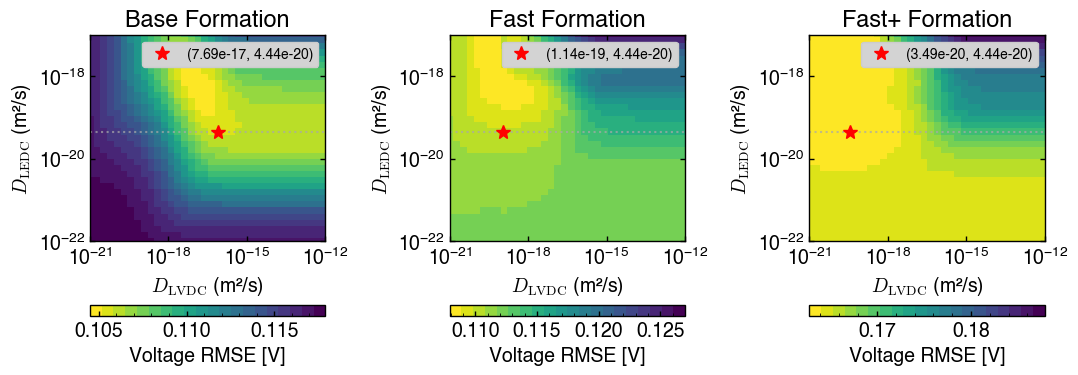

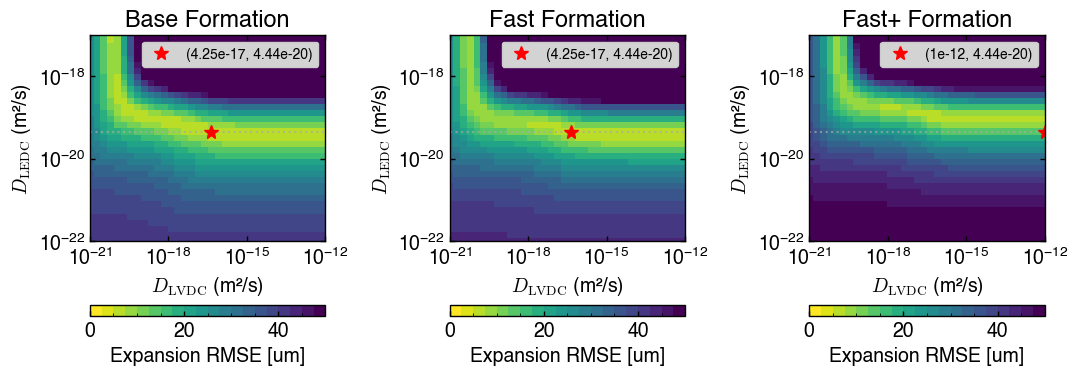

In [4]:
import pickle
%autoreload 2

%matplotlib inline
# Load the pickled simulation results
with open('outputs/simulation_results_vc_20260305_dsei_vc_tuning.pkl', 'rb') as f:
    sim_results = pickle.load(f)
diff_ec_vec = np.logspace(-22, -17, 35)
diff_vc_vec = np.logspace(-21, -12, 36)

# with open('outputs/simulation_results_20250828.pkl', 'rb') as f:
    # sim_results = pickle.load(f)
# diff_ec_vec = np.logspace(-22, -17, 100)
# diff_vc_vec = np.logspace(-21, -12, 101)

# with open('outputs/simulation_results.pkl', 'rb') as f:
    # sim_results = pickle.load(f)
# diff_ec_vec = np.logspace(-22, -17, 25)
# diff_vc_vec = np.logspace(-21, -12, 25)


# Extract variables from the loaded results
rmse1_e_mat = sim_results['rmse1_e_mat']
rmse1_v_mat = sim_results['rmse1_v_mat']
rmse2_e_mat = sim_results['rmse2_e_mat'] 
rmse2_v_mat = sim_results['rmse2_v_mat']
rmse3_e_mat = sim_results['rmse3_e_mat']
rmse3_v_mat = sim_results['rmse3_v_mat']
qsei1_mat = sim_results['qsei1_mat']
qsei2_mat = sim_results['qsei2_mat']
qsei3_mat = sim_results['qsei3_mat']
qsei1_vc_mat = sim_results['qsei1_vc_mat']
qsei2_vc_mat = sim_results['qsei2_vc_mat']
qsei3_vc_mat = sim_results['qsei3_vc_mat']
expan1_mat = sim_results['expan1_mat']
expan2_mat = sim_results['expan2_mat']
expan3_mat = sim_results['expan3_mat']
resistance1_mat = sim_results['resistance1_mat']
resistance2_mat = sim_results['resistance2_mat']
resistance3_mat = sim_results['resistance3_mat']
combined_rmse1 = sim_results['combined_rmse1']
combined_rmse2 = sim_results['combined_rmse2']
combined_rmse3 = sim_results['combined_rmse3']
eq1_mat = sim_results['eq1_mat']
eq2_mat = sim_results['eq2_mat']
eq3_mat = sim_results['eq3_mat']
er1_mat = sim_results['er1_mat'] 
er2_mat = sim_results['er2_mat']
er3_mat = sim_results['er3_mat']
ec1_mat = sim_results['ec1_mat']
ec2_mat = sim_results['ec2_mat']
ec3_mat = sim_results['ec3_mat']
crosstime1_mat = sim_results['crosstime1_mat']
crosstime2_mat = sim_results['crosstime2_mat']
crosstime3_mat = sim_results['crosstime3_mat']

avg_rmse_v_mat = (rmse1_v_mat + rmse2_v_mat + rmse3_v_mat) / 3

simutils.plot_heatmaps_diff(diff_ec_vec, diff_vc_vec, rmse1_v_mat, rmse2_v_mat, rmse3_v_mat, 'Voltage RMSE [V]', 
                                   zmin=None, zmax=None, tosave=True, savename='outputs/figures/heatmap_diff_rmse_v.svg',
                                   to_annotate=True, annotation_orientation='horizontal', annotation_coord=4.44e-20)
# simutils.plot_heatmaps_diff(diff_ec_vec, diff_vc_vec, avg_rmse_v_mat, avg_rmse_v_mat, avg_rmse_v_mat, 'Voltage RMSE [V]', 
                                #    zmin=None, zmax=None, tosave=True, to_annotate=True, savename='outputs/figures/heatmap_diff_rmse_v_avg.svg') 
simutils.plot_heatmaps_diff(diff_ec_vec, diff_vc_vec, rmse1_e_mat, rmse2_e_mat, rmse3_e_mat, 'Expansion RMSE [um]', 
                                   zmin=0, zmax=50, tosave=True, savename='outputs/figures/heatmap_diff_rmse_e.svg',
                                   to_annotate=True, annotation_orientation='horizontal', annotation_coord=4.44e-20)

# simutils.plot_diffusivity_heatmaps(diff_ec_vec, diff_vc_vec, eq1_mat, eq2_mat, eq3_mat, '$E_Q = (Q-\hat{Q})^2$', zmin=0, zmax=0.2, tosave=True, savename='heatmap_eq.svg')
# simutils.plot_diffusivity_heatmaps(diff_ec_vec, diff_vc_vec, er1_mat, er2_mat, er3_mat, '$E_R = (R-\hat{R})^2$', zmin=0, zmax=0.01, tosave=True, savename='heatmap_er.svg')
# simutils.plot_diffusivity_heatmaps(diff_ec_vec, diff_vc_vec, ec1_mat, ec2_mat, ec3_mat, '$E_Q + E_R$', zmin=0.0, zmax=0.05, tosave=True, savename='heatmap_ec.svg')
# simutils.plot_diffusivity_heatmaps(diff_ec_vec, diff_vc_vec, combined_rmse1, combined_rmse2, combined_rmse3, '$RMSE_V + RMSE_{\epsilon}$', zmin=0.00, zmax=0.5, tosave=True, savename='heatmap_combined_rmse.svg')
# simutils.plot_diffusivity_heatmaps(diff_ec_vec, diff_vc_vec, qsei1_vc_mat, qsei2_vc_mat, qsei3_vc_mat, '$Q_{VC}$', is_error_plot=False, tosave=True, savename='heatmap_qsei_vc.svg')

In [ ]:
# df_sim1 = simutils.run_sim('base', dt=1, include_flag=1)
df_sim1 = simutils.run_sim('base', diff_vc=6.31e-17, dt=1, include_flag=1)

%matplotlib widget

crossover_idx = df_sim1[df_sim1['j_sei1'] > df_sim1['j_sei2']].index

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(df_sim1['t'] / 3600, df_sim1['j_sei1'], label='j_sei1 (EC)', color='tab:orange', lw=2)
ax.plot(df_sim1['t'] / 3600, df_sim1['j_sei2'], label='j_sei2 (VC)', color='tab:green', lw=2)

# Add vertical line at crossover point
if len(crossover_idx) > 0:
    crossover_time = df_sim1.loc[crossover_idx[0], 't'] / 3600
    ax.axvline(x=crossover_time, color='red', linestyle='--', lw=1.5, label='Crossover')

ax.set_xlabel('Time (hours)')
ax.set_ylabel('Current density (A/m²)')
ax.set_title('SEI Current Densities')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
# Visual inspection of model vs experiment voltage for first 10 hours
# Using mid-range diffusivity values from the heatmap sweep

# Pick middle values from the diffusivity sweep
d_ec_mid = diff_ec_vec[len(diff_ec_vec)//2]  # Mid-point of EC diffusivity range
d_vc_mid = diff_vc_vec[len(diff_vc_vec)//2]  # Mid-point of VC diffusivity range

print(f"Using D_EC = {d_ec_mid:.2e}, D_VC = {d_vc_mid:.2e}")

# Run simulations for base, fast, fast+ formations
df_sim1_mid = simutils.run_sim('base', d_ec_mid, d_vc_mid, dt=5, include_flag=1)
df_sim2_mid = simutils.run_sim('fast', d_ec_mid, d_vc_mid, dt=5, include_flag=1)
df_sim3_mid = simutils.run_sim('fast+', d_ec_mid, d_vc_mid, dt=1, include_flag=1)

# Find crossover times (when j_sei1 = j_sei2, i.e., EC current equals VC current)
def find_sei_crossover_time(df_sim, t_start=30*60+60, t_end=10*3600):
    """Find the first time after t_start where j_sei1 (EC) crosses j_sei2 (VC)."""
    t = df_sim['t'].values
    j1 = df_sim['j_sei1'].values
    j2 = df_sim['j_sei2'].values
    
    mask = (t >= t_start) & (t <= t_end)
    t_masked = t[mask]
    j1_masked = j1[mask]
    j2_masked = j2[mask]
    
    # Find sign changes in the difference (j1 - j2)
    # Crossover is when j1 goes from < j2 to > j2
    diff = j1_masked - j2_masked
    sign_changes = np.where(np.diff(np.sign(diff)))[0]
    
    if len(sign_changes) > 0:
        return t_masked[sign_changes[0]] / 3600  # Return in hours
    return np.nan

# Calculate crossover times (when j_EC = j_VC)
crossover1 = find_sei_crossover_time(df_sim1_mid)
crossover2 = find_sei_crossover_time(df_sim2_mid)
crossover3 = find_sei_crossover_time(df_sim3_mid)

print(f"Crossover times (j_EC = j_VC): Base={crossover1:.2f}h, Fast={crossover2:.2f}h, Fast+={crossover3:.2f}h")

# Create the comparison plot
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

xlim = 1.5  # First 10 hours

# Base Formation
ax = axs[0]
t_exp = expt1['arbin_time'] / 3600
t_mod = df_sim1_mid['t'] / 3600
ax.plot(t_exp, expt1['arbin_voltage'], 'b-', lw=1.5, label='Experiment')
ax.plot(t_mod, df_sim1_mid['vt'], 'b--', lw=1.5, label='Model')
if not np.isnan(crossover1):
    ax.axvline(x=crossover1, color='r', ls=':', lw=2, label=f'Crossover @ {crossover1:.2f}h')
ax.axvline(x=0.5, color='gray', ls='--', lw=1, alpha=0.5, label='30 min (RMSE start)')
ax.set_xlim(0, xlim)
ax.set_ylim(0.0, 4.5)
ax.set_xlabel('Time [hrs]')
ax.set_ylabel('Voltage [V]')
ax.set_title('Base Formation')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

# Fast Formation
ax = axs[1]
t_exp = expt3['arbin_time'] / 3600
t_mod = df_sim2_mid['t'] / 3600
ax.plot(t_exp, expt3['arbin_voltage'], 'g-', lw=1.5, label='Experiment')
ax.plot(t_mod, df_sim2_mid['vt'], 'g--', lw=1.5, label='Model')
if not np.isnan(crossover2):
    ax.axvline(x=crossover2, color='r', ls=':', lw=2, label=f'Crossover @ {crossover2:.2f}h')
ax.axvline(x=0.5, color='gray', ls='--', lw=1, alpha=0.5, label='30 min (RMSE start)')
ax.set_xlim(0, xlim)
ax.set_ylim(0.0, 4.5)
ax.set_xlabel('Time [hrs]')
ax.set_ylabel('Voltage [V]')
ax.set_title('Fast Formation')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

# Fast+ Formation
ax = axs[2]
t_exp = expt4['arbin_time'] / 3600
t_mod = df_sim3_mid['t'] / 3600
ax.plot(t_exp, expt4['arbin_voltage'], 'm-', lw=1.5, label='Experiment')
ax.plot(t_mod, df_sim3_mid['vt'], 'm--', lw=1.5, label='Model')
if not np.isnan(crossover3):
    ax.axvline(x=crossover3, color='r', ls=':', lw=2, label=f'Crossover @ {crossover3:.2f}h')
ax.axvline(x=0.5, color='gray', ls='--', lw=1, alpha=0.5, label='30 min (RMSE start)')
ax.set_xlim(0, xlim)
ax.set_ylim(0.0, 4.5)
ax.set_xlabel('Time [hrs]')
ax.set_ylabel('Voltage [V]')
ax.set_title('Fast+ Formation')
ax.legend(loc='lower right', fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle(f'Model vs Experiment Voltage (D_EC={d_ec_mid:.2e}, D_VC={d_vc_mid:.2e})', 
             y=1.02, fontsize=12)
plt.show()

print(f"\nRMSE region: 30 min to crossover time (when j_EC = j_VC)")
print(f"Visual inspection of voltage gap in this region helps assess model fit quality.")

In [ ]:
%matplotlib widget 

# Optimized densities from baseline formation, expansion RMSE
rho_vc_opt = 1.3
rho_ec_opt = 0.8

d_ec = 3.86e-20
d_vc = 1.585e-17

df_fast = simutils.run_sim('fast', d_ec, d_vc, rho_ec=rho_ec_opt, rho_vc=rho_vc_opt, dt=1, include_flag=1)

fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)

# Experimental data (fast protocol)
exp_time = expt3['daq_time'] / 3600  # convert seconds to hours
exp_strain = expt3['daq_strain']

# Model data
model_time = df_fast['t'] / 3600  # convert seconds to hours
model_expansion = df_fast['expansion'] * 1e6  # convert m to um

# Top plot: Expansion
axes[0].plot(exp_time, exp_strain, label='Experimental', color='k', lw=2)
axes[0].plot(model_time, model_expansion, label='Model', color='tab:blue', lw=2)
axes[0].set_ylabel('Expansion (µm)')
axes[0].set_title('Model vs Experimental Expansion (Fast Protocol)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Bottom plot: SEI current densities
axes[1].plot(model_time, df_fast['j_sei1'], label='j_sei1 (EC)', color='tab:orange', lw=2)
axes[1].plot(model_time, df_fast['j_sei2'], label='j_sei2 (VC)', color='tab:green', lw=2)
axes[1].set_xlabel('Time (hours)')
axes[1].set_ylabel('Current density (A/m²)')
axes[1].set_title('SEI Current Densities (Fast Protocol)')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

# Set shared x-axis limits
axes[1].set_xlim(0.4, 1)

plt.tight_layout()
plt.show()

In [ ]:
# Complementary plot: SEI current densities (j_sei1 vs j_sei2)
# Verify that crossover point is when j_sei1 (EC) > j_sei2 (VC)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

xlim = 1.5  # First 10 hours

# Base Formation
ax = axs[0]
t_mod = df_sim1_mid['t'] / 3600
ax.plot(t_mod, df_sim1_mid['j_sei1'], 'c-', lw=1.5, label=r'$j_{EC}$ (SEI1)')
ax.plot(t_mod, df_sim1_mid['j_sei2'], 'm-', lw=1.5, label=r'$j_{VC}$ (SEI2)')
if not np.isnan(crossover1):
    ax.axvline(x=crossover1, color='r', ls=':', lw=2, label=f'Crossover @ {crossover1:.2f}h')
    # Find and mark the j values at crossover
    idx_cross = np.argmin(np.abs(t_mod - crossover1))
    j1_cross = df_sim1_mid['j_sei1'].iloc[idx_cross]
    j2_cross = df_sim1_mid['j_sei2'].iloc[idx_cross]
    ax.plot(crossover1, j1_cross, 'co', markersize=8)
    ax.plot(crossover1, j2_cross, 'mo', markersize=8)
    ax.annotate(f'j_EC={j1_cross:.1e}', (crossover1, j1_cross), textcoords="offset points", 
                xytext=(10, 5), fontsize=7, color='c')
    ax.annotate(f'j_VC={j2_cross:.1e}', (crossover1, j2_cross), textcoords="offset points", 
                xytext=(10, -10), fontsize=7, color='m')
ax.set_xlim(0, xlim)
# # ax.set_yscale('log')
# ax.set_ylim(1e-4, 1e1)
ax.set_xlabel('Time [hrs]')
ax.set_ylabel(r'Current Density [A/m$^2$]')
ax.set_title('Base Formation')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3, which='both')

# Fast Formation
ax = axs[1]
t_mod = df_sim2_mid['t'] / 3600
ax.plot(t_mod, df_sim2_mid['j_sei1'], 'c-', lw=1.5, label=r'$j_{EC}$ (SEI1)')
ax.plot(t_mod, df_sim2_mid['j_sei2'], 'm-', lw=1.5, label=r'$j_{VC}$ (SEI2)')
if not np.isnan(crossover2):
    ax.axvline(x=crossover2, color='r', ls=':', lw=2, label=f'Crossover @ {crossover2:.2f}h')
    idx_cross = np.argmin(np.abs(t_mod - crossover2))
    j1_cross = df_sim2_mid['j_sei1'].iloc[idx_cross]
    j2_cross = df_sim2_mid['j_sei2'].iloc[idx_cross]
    ax.plot(crossover2, j1_cross, 'co', markersize=8)
    ax.plot(crossover2, j2_cross, 'mo', markersize=8)
    ax.annotate(f'j_EC={j1_cross:.1e}', (crossover2, j1_cross), textcoords="offset points", 
                xytext=(10, 5), fontsize=7, color='c')
    ax.annotate(f'j_VC={j2_cross:.1e}', (crossover2, j2_cross), textcoords="offset points", 
                xytext=(10, -10), fontsize=7, color='m')
ax.set_xlim(0, xlim)
# ax.set_yscale('log')
# ax.set_ylim(1e-4, 1e1)
ax.set_xlabel('Time [hrs]')
ax.set_ylabel(r'Current Density [A/m$^2$]')
ax.set_title('Fast Formation')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3, which='both')

# Fast+ Formation
ax = axs[2]
t_mod = df_sim3_mid['t'] / 3600
ax.plot(t_mod, df_sim3_mid['j_sei1'], 'c-', lw=1.5, label=r'$j_{EC}$ (SEI1)')
ax.plot(t_mod, df_sim3_mid['j_sei2'], 'm-', lw=1.5, label=r'$j_{VC}$ (SEI2)')
if not np.isnan(crossover3):
    ax.axvline(x=crossover3, color='r', ls=':', lw=2, label=f'Crossover @ {crossover3:.2f}h')
    idx_cross = np.argmin(np.abs(t_mod - crossover3))
    j1_cross = df_sim3_mid['j_sei1'].iloc[idx_cross]
    j2_cross = df_sim3_mid['j_sei2'].iloc[idx_cross]
    ax.plot(crossover3, j1_cross, 'co', markersize=8)
    ax.plot(crossover3, j2_cross, 'mo', markersize=8)
    ax.annotate(f'j_EC={j1_cross:.1e}', (crossover3, j1_cross), textcoords="offset points", 
                xytext=(10, 5), fontsize=7, color='c')
    ax.annotate(f'j_VC={j2_cross:.1e}', (crossover3, j2_cross), textcoords="offset points", 
                xytext=(10, -10), fontsize=7, color='m')
ax.set_xlim(0, xlim)
# ax.set_yscale('log')
# ax.set_ylim(1e-4, 1e1)
ax.set_xlabel('Time [hrs]')
ax.set_ylabel(r'Current Density [A/m$^2$]')
ax.set_title('Fast+ Formation')
ax.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.suptitle(r'SEI Current Densities: $j_{EC}$ (SEI1) vs $j_{VC}$ (SEI2)', y=1.02, fontsize=12)
plt.show()

# Verify crossover condition
print("\nVerification: At crossover point, j_EC should exceed j_VC")
for name, df, crossover in [('Base', df_sim1_mid, crossover1), 
                             ('Fast', df_sim2_mid, crossover2), 
                             ('Fast+', df_sim3_mid, crossover3)]:
    if not np.isnan(crossover):
        t_mod = df['t'] / 3600
        idx = np.argmin(np.abs(t_mod - crossover))
        j1 = df['j_sei1'].iloc[idx]
        j2 = df['j_sei2'].iloc[idx]
        status = "✓ VERIFIED" if j1 > j2 else "✗ NOT VERIFIED"
        print(f"  {name}: j_EC={j1:.2e}, j_VC={j2:.2e}, j_EC > j_VC? {status}")

# Tune $\rho_1, \rho_2$

In [9]:
nn = 35

rho_ec_vec = np.linspace(0.1, 4, nn)
rho_vc_vec = np.linspace(0.1, 4, nn+1)

shape = (len(rho_ec_vec), len(rho_vc_vec))
_mat_names = [
    'rmse1_e_mat', 'rmse1_v_mat', 'rmse2_e_mat', 'rmse2_v_mat', 'rmse3_e_mat', 'rmse3_v_mat',
    'qsei1_mat', 'qsei2_mat', 'qsei3_mat', 'qsei1_vc_mat', 'qsei2_vc_mat', 'qsei3_vc_mat',
    'expan1_mat', 'expan2_mat', 'expan3_mat',
    'resistance1_mat', 'resistance2_mat', 'resistance3_mat',
    'crossover1_mat', 'crossover2_mat', 'crossover3_mat',
]
mats = {n: np.zeros(shape) for n in _mat_names}
(rmse1_e_mat, rmse1_v_mat, rmse2_e_mat, rmse2_v_mat, rmse3_e_mat, rmse3_v_mat,
 qsei1_mat, qsei2_mat, qsei3_mat, qsei1_vc_mat, qsei2_vc_mat, qsei3_vc_mat,
 expan1_mat, expan2_mat, expan3_mat, resistance1_mat, resistance2_mat, resistance3_mat,
 crossover1_mat, crossover2_mat, crossover3_mat) = tuple(mats[n] for n in _mat_names)

count = 1

kappa_vc_opt = 0.051e-3
kappa_ec_opt = 0.090e-3

for i, rho_ec in enumerate(rho_ec_vec):
    for j, rho_vc in enumerate(rho_vc_vec):

        print(f'Running rho_EC = {rho_ec:.2e} | rho_VC = {rho_vc:.2e} ({count} of {nn*(nn+1)})')
        count += 1

        try:
            df_sim1 = simutils.run_sim('base', diff_vc=7.69e-17, diff_ec=4.44e-20, rho_ec=rho_ec, rho_vc=rho_vc, kappa_ec=kappa_ec_opt, kappa_vc=kappa_vc_opt, dt=1, include_flag=0)
            df_sim2 = simutils.run_sim('fast', diff_vc=1.14e-19, diff_ec=4.44e-20, rho_ec=rho_ec, rho_vc=rho_vc, kappa_ec=kappa_ec_opt, kappa_vc=kappa_vc_opt, dt=1, include_flag=0)
            df_sim3 = simutils.run_sim('fast+', diff_vc=3.49e-20, diff_ec=4.44e-20, rho_ec=rho_ec, rho_vc=rho_vc, kappa_ec=kappa_ec_opt, kappa_vc=kappa_vc_opt, dt=1, include_flag=0)

        except:
            print('ERROR')
            continue
        
        # Extract the qsei values:
        qsei1_mat[i, j] = df_sim1['q_sei'].iloc[-1]
        qsei2_mat[i, j] = df_sim2['q_sei'].iloc[-1]
        qsei3_mat[i, j] = df_sim3['q_sei'].iloc[-1]

        qsei1_vc_mat[i, j] = df_sim1['q_sei2'].iloc[-1]
        qsei2_vc_mat[i, j] = df_sim2['q_sei2'].iloc[-1]
        qsei3_vc_mat[i, j] = df_sim3['q_sei2'].iloc[-1]

        # Extract the expansion values:
        expan1_mat[i, j] = df_sim1['expansion'].iloc[-1]
        expan2_mat[i, j] = df_sim2['expansion'].iloc[-1]
        expan3_mat[i, j] = df_sim3['expansion'].iloc[-1]

        # Extract the resistance values:
        resistance1_mat[i, j] = df_sim1['R_sei'].iloc[-1]
        resistance2_mat[i, j] = df_sim2['R_sei'].iloc[-1]
        resistance3_mat[i, j] = df_sim3['R_sei'].iloc[-1]

        # Beware of experimental vs model data indexing!!
        rmse1_v, _, _ = simutils.calculate_rmse(expt2['arbin_time'], expt2['arbin_voltage'], df_sim1['t'], df_sim1['vt'], ignore_time_range=((0,30*60)))
        rmse1_e, _, _ = simutils.calculate_rmse(expt2['daq_time'],   expt2['daq_strain_smoothed'], df_sim1['t'], df_sim1['expansion']*1e6, ignore_time_range=((0,30*60)))
        rmse2_v, _, _ = simutils.calculate_rmse(expt3['arbin_time'], expt3['arbin_voltage'], df_sim2['t'], df_sim2['vt'], ignore_time_range=((0,30*60)))
        rmse2_e, _, _ = simutils.calculate_rmse(expt3['daq_time'],   expt3['daq_strain_smoothed'], df_sim2['t'], df_sim2['expansion']*1e6, ignore_time_range=((0,30*60)))
        rmse3_v, _, _ = simutils.calculate_rmse(expt4['arbin_time'], expt4['arbin_voltage'], df_sim3['t'], df_sim3['vt'], ignore_time_range=((0,30*60)))
        rmse3_e, _, _ = simutils.calculate_rmse(expt4['daq_time'],   expt4['daq_strain_smoothed'], df_sim3['t'], df_sim3['expansion']*1e6, ignore_time_range=((0,30*60)))

        rmse1_e_mat[i, j] = rmse1_e
        rmse1_v_mat[i, j] = rmse1_v
        rmse2_e_mat[i, j] = rmse2_e
        rmse2_v_mat[i, j] = rmse2_v
        rmse3_e_mat[i, j] = rmse3_e
        rmse3_v_mat[i, j] = rmse3_v

# Replace zeros with np.nan (failed runs)
for n in _mat_names:
    mats[n] = np.where(mats[n] == 0, np.nan, mats[n])
(rmse1_e_mat, rmse1_v_mat, rmse2_e_mat, rmse2_v_mat, rmse3_e_mat, rmse3_v_mat,
 qsei1_mat, qsei2_mat, qsei3_mat, qsei1_vc_mat, qsei2_vc_mat, qsei3_vc_mat,
 expan1_mat, expan2_mat, expan3_mat, resistance1_mat, resistance2_mat, resistance3_mat,
 crossover1_mat, crossover2_mat, crossover3_mat) = tuple(mats[n] for n in _mat_names)

combined_rmse1 = rmse1_e_mat/np.nanmax(rmse1_e_mat) + rmse1_v_mat/np.nanmax(rmse1_v_mat)
combined_rmse2 = rmse2_e_mat/np.nanmax(rmse2_e_mat) + rmse2_v_mat/np.nanmax(rmse2_v_mat)
combined_rmse3 = rmse3_e_mat/np.nanmax(rmse3_e_mat) + rmse3_v_mat/np.nanmax(rmse3_v_mat)

# Compute error metrics based on cell capacity and resistance
# Rother = 0.01 + 0.001 + 0.001 # R0p + Rdiffp + Rdiffn
Rother = 0.0215 - 0.09197987391102377 # This value gets the R error to 0 for the base case
Rmeas1 = 0.0215 
Rmeas2 = 0.0178 
Rmeas3 = 0.0166 
Q_max  = 2.87
Q_meas = 2.54

# Capacity error
eq1_mat = (qsei1_mat - (Q_max - Q_meas))**2
eq2_mat = (qsei2_mat - (Q_max - Q_meas))**2
eq3_mat = (qsei3_mat - (Q_max - Q_meas))**2

# Resistance error
er1_mat = ((resistance1_mat + Rother) - Rmeas1)**2
er2_mat = ((resistance2_mat + Rother) - Rmeas2)**2
er3_mat = ((resistance3_mat + Rother) - Rmeas3)**2

# Combined capacity and resistance error
ec1_mat = (eq1_mat / np.nanmax(eq1_mat)) + (er1_mat / np.nanmax(er1_mat))
ec2_mat = (eq2_mat / np.nanmax(eq2_mat)) + (er2_mat / np.nanmax(er2_mat))
ec3_mat = (eq3_mat / np.nanmax(eq3_mat)) + (er3_mat / np.nanmax(er3_mat))

Running rho_EC = 1.00e-01 | rho_VC = 1.00e-01 (1 of 1260)
Running rho_EC = 1.00e-01 | rho_VC = 2.11e-01 (2 of 1260)
Running rho_EC = 1.00e-01 | rho_VC = 3.23e-01 (3 of 1260)
Running rho_EC = 1.00e-01 | rho_VC = 4.34e-01 (4 of 1260)
Running rho_EC = 1.00e-01 | rho_VC = 5.46e-01 (5 of 1260)
Running rho_EC = 1.00e-01 | rho_VC = 6.57e-01 (6 of 1260)
Running rho_EC = 1.00e-01 | rho_VC = 7.69e-01 (7 of 1260)
Running rho_EC = 1.00e-01 | rho_VC = 8.80e-01 (8 of 1260)
Running rho_EC = 1.00e-01 | rho_VC = 9.91e-01 (9 of 1260)
Running rho_EC = 1.00e-01 | rho_VC = 1.10e+00 (10 of 1260)
Running rho_EC = 1.00e-01 | rho_VC = 1.21e+00 (11 of 1260)
Running rho_EC = 1.00e-01 | rho_VC = 1.33e+00 (12 of 1260)
Running rho_EC = 1.00e-01 | rho_VC = 1.44e+00 (13 of 1260)
Running rho_EC = 1.00e-01 | rho_VC = 1.55e+00 (14 of 1260)
Running rho_EC = 1.00e-01 | rho_VC = 1.66e+00 (15 of 1260)
Running rho_EC = 1.00e-01 | rho_VC = 1.77e+00 (16 of 1260)
Running rho_EC = 1.00e-01 | rho_VC = 1.88e+00 (17 of 1260)
Runnin

In [10]:
variables_to_pickle = {
    'rmse1_e_mat': rmse1_e_mat,
    'rmse1_v_mat': rmse1_v_mat,
    'rmse2_e_mat': rmse2_e_mat,
    'rmse2_v_mat': rmse2_v_mat,
    'rmse3_e_mat': rmse3_e_mat,
    'rmse3_v_mat': rmse3_v_mat,
    'qsei1_mat': qsei1_mat,
    'qsei2_mat': qsei2_mat,
    'qsei3_mat': qsei3_mat,
    'qsei1_vc_mat': qsei1_vc_mat,
    'qsei2_vc_mat': qsei2_vc_mat,
    'qsei3_vc_mat': qsei3_vc_mat,
    'expan1_mat': expan1_mat,
    'expan2_mat': expan2_mat,
    'expan3_mat': expan3_mat,
    'resistance1_mat': resistance1_mat,
    'resistance2_mat': resistance2_mat,
    'resistance3_mat': resistance3_mat,
    'combined_rmse1': combined_rmse1,
    'combined_rmse2': combined_rmse2,
    'combined_rmse3': combined_rmse3,
    'eq1_mat': eq1_mat,
    'eq2_mat': eq2_mat,
    'eq3_mat': eq3_mat,
    'er1_mat': er1_mat,
    'er2_mat': er2_mat,
    'er3_mat': er3_mat,
    'ec1_mat': ec1_mat,
    'ec2_mat': ec2_mat,
    'ec3_mat': ec3_mat
}

with open('outputs/simulation_results_density_vc_20260312.pkl', 'wb') as f:
    pickle.dump(variables_to_pickle, f)

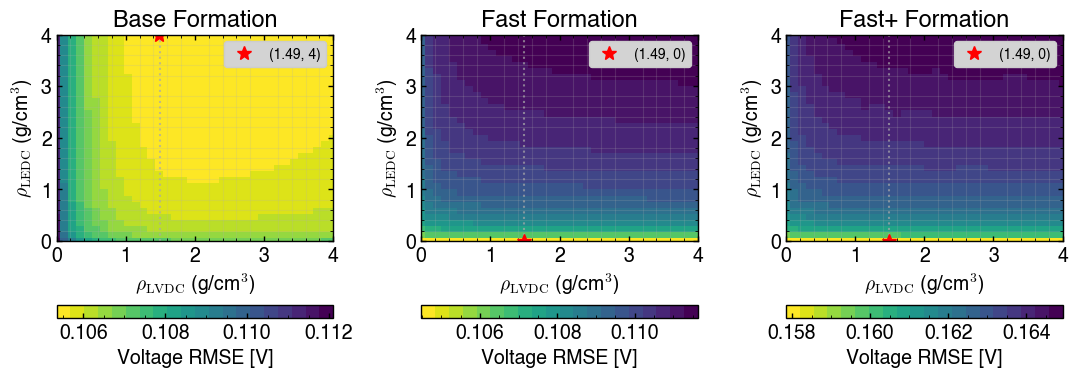

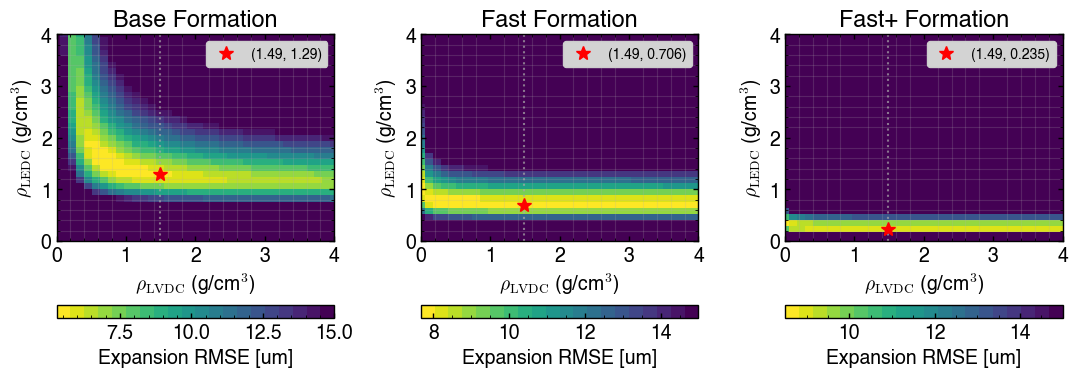

In [6]:

%autoreload 2

%matplotlib inline
# Load the pickled simulation results
with open('outputs/simulation_results_density_vc_20260312.pkl', 'rb') as f:
    sim_results = pickle.load(f)
diff_ec_vec = np.linspace(0.0, 4.0, 35)
diff_vc_vec = np.linspace(0.0, 4.0, 36)

# Extract variables from the loaded results
rmse1_e_mat = sim_results['rmse1_e_mat']
rmse1_v_mat = sim_results['rmse1_v_mat']
rmse2_e_mat = sim_results['rmse2_e_mat'] 
rmse2_v_mat = sim_results['rmse2_v_mat']
rmse3_e_mat = sim_results['rmse3_e_mat']
rmse3_v_mat = sim_results['rmse3_v_mat']
qsei1_mat = sim_results['qsei1_mat']
qsei2_mat = sim_results['qsei2_mat']
qsei3_mat = sim_results['qsei3_mat']
qsei1_vc_mat = sim_results['qsei1_vc_mat']
qsei2_vc_mat = sim_results['qsei2_vc_mat']
qsei3_vc_mat = sim_results['qsei3_vc_mat']
expan1_mat = sim_results['expan1_mat']
expan2_mat = sim_results['expan2_mat']
expan3_mat = sim_results['expan3_mat']
resistance1_mat = sim_results['resistance1_mat']
resistance2_mat = sim_results['resistance2_mat']
resistance3_mat = sim_results['resistance3_mat']
combined_rmse1 = sim_results['combined_rmse1']
combined_rmse2 = sim_results['combined_rmse2']
combined_rmse3 = sim_results['combined_rmse3']
eq1_mat = sim_results['eq1_mat']
eq2_mat = sim_results['eq2_mat']
eq3_mat = sim_results['eq3_mat']
er1_mat = sim_results['er1_mat'] 
er2_mat = sim_results['er2_mat']
er3_mat = sim_results['er3_mat']
ec1_mat = sim_results['ec1_mat']
ec2_mat = sim_results['ec2_mat']
ec3_mat = sim_results['ec3_mat']


simutils.plot_heatmaps_rho(diff_ec_vec, diff_vc_vec, rmse1_v_mat, rmse2_v_mat, rmse3_v_mat, 'Voltage RMSE [V]', 
                                   zmin=None, zmax=None, tosave=True, savename='outputs/figures/heatmap_rho_rmse_v.svg',
                                   to_annotate=True, annotation_orientation='vertical', annotation_coord=1.49)
simutils.plot_heatmaps_rho(diff_ec_vec, diff_vc_vec, rmse1_e_mat, rmse2_e_mat, rmse3_e_mat, 'Expansion RMSE [um]', 
                                   zmin=None, zmax=15, tosave=True, savename='outputs/figures/heatmap_rho_rmse_e.svg',
                                   to_annotate=True, annotation_orientation='vertical', annotation_coord=1.49)